<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/20B_NeuroFHIR_TRACE_REAL_Three_State_Gate_Calibration_CORRECTED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 20B-REAL-CORRECTED
## Stable Outcome-Blind Three-State Reliability Gate Using Real ADNI1 Repeatability

This notebook corrects the first 20B-REAL gate in two ways:

1. **Technical thresholds are stabilized** using repeated subject-level cross-validation and subject-level bootstrap across the real same-day acquisition-repeat cohort.
2. **Subject-level review does not double-count bilateral features** that share one underlying QC failure. Package-level review is based on unique root-cause flags, not the number of affected left/right biomarkers.

### Real evidence used
- 75 same-day different-acquisition repeat pairs — primary technical reliability reference.
- 15 same-source repeated-processing pairs — secondary sensitivity analysis.
- 258 real ADNI1 baseline→12-month longitudinal subjects.

### Primary threshold choice
The **90th percentile (Q90)** of same-day absolute percent disagreement is the primary evidence threshold. Q90 is used because the real repeat cohort is modest in size and the earlier single-split Q95 estimate was unstable. Q95 is retained as a conservative sensitivity threshold and as the threshold for hard ICV-instability review.

### Three states
- **TRUSTED**: clean QC and longitudinal change exceeds the locked Q90 technical envelope.
- **CAUTION**: no hard reliability failure, but the evidence does not meet the TRUSTED criterion.
- **REVIEW_REQUIRED**: a hard QC/provenance concern exists.

These states quantify the **reliability of longitudinal imaging evidence**. They do not establish diagnosis, biological truth, clinical safety, or patient benefit.


In [21]:

from pathlib import Path
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 2027
rng = np.random.default_rng(SEED)

OUTDIR = Path("trace_20b_real_corrected_outputs")
OUTDIR.mkdir(exist_ok=True)

print("Output directory:", OUTDIR.resolve())


Output directory: /content/trace_20b_real_corrected_outputs



## 1. Upload the two private ADNI-derived CSVs through Colab's **Files** pane

Upload:

- `TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv`
- `TRACE_ADNI1_repeat_pairs_REAL.csv`

Do not use `google.colab.files.upload()`. Wait until both appear under `/content`, then run the loader cell.


In [22]:

EXPECTED_LONG = "TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv"
EXPECTED_REP = "TRACE_ADNI1_repeat_pairs_REAL.csv"

SEARCH_DIRS = [Path("/content"), Path.cwd(), Path("/mnt/data")]

def find_file(expected_name):
    stem = Path(expected_name).stem
    suffix = Path(expected_name).suffix.lower()

    for d in SEARCH_DIRS:
        p = d / expected_name
        if p.exists():
            return p

    candidates = []
    for d in SEARCH_DIRS:
        if d.exists():
            candidates.extend(
                p for p in d.glob(f"{stem}*{suffix}") if p.is_file()
            )

    if not candidates:
        return None

    return sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]

LONGITUDINAL_PATH = find_file(EXPECTED_LONG)
REPEAT_PATH = find_file(EXPECTED_REP)

if LONGITUDINAL_PATH is None or REPEAT_PATH is None:
    missing = []
    if LONGITUDINAL_PATH is None:
        missing.append(EXPECTED_LONG)
    if REPEAT_PATH is None:
        missing.append(EXPECTED_REP)
    raise FileNotFoundError(
        "Missing required file(s): " + ", ".join(missing) +
        ". Upload both using the Colab left Files pane, then rerun this cell."
    )

long_df = pd.read_csv(LONGITUDINAL_PATH)
rep_df = pd.read_csv(REPEAT_PATH)

print("Using longitudinal file:", LONGITUDINAL_PATH)
print("Using repeat-pair file:", REPEAT_PATH)
print("Longitudinal shape:", long_df.shape)
print("Repeat-pair shape:", rep_df.shape)


Using longitudinal file: /content/TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv
Using repeat-pair file: /content/TRACE_ADNI1_repeat_pairs_REAL.csv
Longitudinal shape: (258, 51)
Repeat-pair shape: (90, 51)


## 2. Schema and cohort audit

In [23]:

FEATURES = [
    "LHIPPOC",
    "RHIPPOC",
    "LENTORHIN",
    "RENTORHIN",
    "LMIDTEMP",
    "RMIDTEMP",
    "VENTRICLES",
    "ICV",
]
BIO_FEATURES = [f for f in FEATURES if f != "ICV"]

ACQ_TYPE = "SAME_DAY_DIFFERENT_ACQUISITION"
REPROC_TYPE = "SAME_SOURCE_REPROCESSING"

required_long = (
    ["RID", "LABEL", "BL_OVERALLQC", "M12_OVERALLQC",
     "BL_TEMPQC", "M12_TEMPQC", "BL_VENTQC", "M12_VENTQC"]
    + [f"BL_{f}" for f in FEATURES]
    + [f"M12_{f}" for f in FEATURES]
)

required_rep = (
    ["RID", "REPEAT_TYPE", "QC_1", "QC_2",
     "TEMPQC_1", "TEMPQC_2", "VENTQC_1", "VENTQC_2"]
    + [f"PCT_DIFF_{f}" for f in FEATURES]
)

missing_long = [c for c in required_long if c not in long_df.columns]
missing_rep = [c for c in required_rep if c not in rep_df.columns]

if missing_long:
    raise ValueError(f"Missing longitudinal columns: {missing_long}")
if missing_rep:
    raise ValueError(f"Missing repeat columns: {missing_rep}")

acq = rep_df.loc[rep_df["REPEAT_TYPE"] == ACQ_TYPE].copy()
reproc = rep_df.loc[rep_df["REPEAT_TYPE"] == REPROC_TYPE].copy()

print("Longitudinal subjects:", long_df["RID"].nunique())
print("Same-day acquisition pairs:", len(acq))
print("Same-day acquisition subjects:", acq["RID"].nunique())
print("Repeated-processing pairs:", len(reproc))
print("Repeated-processing subjects:", reproc["RID"].nunique())


Longitudinal subjects: 258
Same-day acquisition pairs: 75
Same-day acquisition subjects: 60
Repeated-processing pairs: 15
Repeated-processing subjects: 12



## 3. Repeated subject-level cross-validation of technical envelopes

A single 70/30 split is too unstable for extreme quantiles with this cohort size.

This analysis therefore uses **repeated subject-level 5-fold cross-validation**:

- subjects, not rows, are assigned to folds;
- for each fold, thresholds are estimated from training subjects;
- coverage is evaluated on held-out subjects;
- the process is repeated 25 times.

Both Q90 and Q95 are evaluated. The goal is not to tune against clinical outcomes; it is to quantify the stability and transportability of the technical envelope.


In [24]:

def make_subject_folds(subjects, n_splits=5, local_rng=None):
    subjects = np.array(subjects)
    perm = subjects.copy()
    local_rng.shuffle(perm)
    return np.array_split(perm, n_splits)

CV_REPEATS = 25
N_SPLITS = 5

unique_subjects = np.array(sorted(acq["RID"].dropna().unique()))
cv_rows = []

for repeat_idx in range(CV_REPEATS):
    local_rng = np.random.default_rng(SEED + repeat_idx)
    folds = make_subject_folds(unique_subjects, n_splits=N_SPLITS, local_rng=local_rng)

    for fold_idx, test_subjects in enumerate(folds):
        test_subjects = set(test_subjects.tolist())
        train = acq.loc[~acq["RID"].isin(test_subjects)]
        test = acq.loc[acq["RID"].isin(test_subjects)]

        for f in FEATURES:
            tr = pd.to_numeric(train[f"PCT_DIFF_{f}"], errors="coerce").dropna().to_numpy()
            te = pd.to_numeric(test[f"PCT_DIFF_{f}"], errors="coerce").dropna().to_numpy()

            if len(tr) == 0 or len(te) == 0:
                continue

            for q in [90, 95]:
                threshold = float(np.percentile(tr, q))
                cv_rows.append({
                    "repeat": repeat_idx,
                    "fold": fold_idx,
                    "feature": f,
                    "quantile": q,
                    "train_pairs": len(tr),
                    "test_pairs": len(te),
                    "threshold_pct": threshold,
                    "heldout_coverage_pct": 100.0 * float(np.mean(te <= threshold)),
                    "heldout_exceedance_pct": 100.0 * float(np.mean(te > threshold)),
                })

cv = pd.DataFrame(cv_rows)

cv_summary = (
    cv.groupby(["feature", "quantile"])
      .agg(
          folds=("heldout_coverage_pct", "size"),
          mean_coverage_pct=("heldout_coverage_pct", "mean"),
          median_coverage_pct=("heldout_coverage_pct", "median"),
          sd_coverage_pct=("heldout_coverage_pct", "std"),
          p10_coverage_pct=("heldout_coverage_pct", lambda x: np.percentile(x, 10)),
          p90_coverage_pct=("heldout_coverage_pct", lambda x: np.percentile(x, 90)),
          median_threshold_pct=("threshold_pct", "median"),
      )
      .reset_index()
)

cv_summary.round(2)


,feature,quantile,folds,mean_coverage_pct,median_coverage_pct,sd_coverage_pct,p10_coverage_pct,p90_coverage_pct,median_threshold_pct
0,ICV,90,125,88.46,88.89,10.08,76.65,100.0,0.36
1,ICV,95,125,93.26,93.75,7.55,85.71,100.0,0.70
2,LENTORHIN,90,125,88.41,88.24,8.45,76.99,100.0,31.50
3,LENTORHIN,95,125,93.96,93.75,6.41,86.10,100.0,44.30
4,LHIPPOC,90,125,88.79,92.31,9.30,76.65,100.0,8.77
5,LHIPPOC,95,125,93.04,93.33,7.07,80.50,100.0,10.99
6,LMIDTEMP,90,125,88.58,92.31,9.79,75.59,100.0,10.19
7,LMIDTEMP,95,125,93.33,93.75,7.28,84.62,100.0,14.44
8,RENTORHIN,90,125,88.82,88.24,9.05,76.92,100.0,41.84
9,RENTORHIN,95,125,93.22,93.75,7.47,83.85,100.0,53.02



## 4. Subject-level bootstrap uncertainty for final thresholds

The final threshold is estimated using **all 75 same-day acquisition pairs**, but uncertainty is assessed by resampling subjects rather than rows.

Q90 is the primary threshold. Q95 is retained for conservative sensitivity and the ICV hard-review rule.


In [25]:

def cluster_bootstrap_quantile(df, feature, q, n_boot=2000, seed=SEED):
    local_rng = np.random.default_rng(seed)
    subjects = np.array(sorted(df["RID"].dropna().unique()))
    out = []

    grouped = {rid: g for rid, g in df.groupby("RID")}

    for _ in range(n_boot):
        sampled = local_rng.choice(subjects, size=len(subjects), replace=True)
        vals = []
        for rid in sampled:
            z = pd.to_numeric(
                grouped[rid][f"PCT_DIFF_{feature}"],
                errors="coerce"
            ).dropna().to_numpy()
            vals.extend(z.tolist())

        if len(vals):
            out.append(np.percentile(vals, q))

    return np.asarray(out, dtype=float)

threshold_rows = []

for f in FEATURES:
    vals = pd.to_numeric(acq[f"PCT_DIFF_{f}"], errors="coerce").dropna().to_numpy()

    boot90 = cluster_bootstrap_quantile(acq, f, 90, n_boot=2000, seed=SEED)
    boot95 = cluster_bootstrap_quantile(acq, f, 95, n_boot=2000, seed=SEED + 100)

    threshold_rows.append({
        "feature": f,
        "n_pairs": len(vals),
        "n_subjects": acq["RID"].nunique(),
        "q50_pct": float(np.percentile(vals, 50)),
        "q90_pct": float(np.percentile(vals, 90)),
        "q90_boot_ci_low": float(np.percentile(boot90, 2.5)),
        "q90_boot_ci_high": float(np.percentile(boot90, 97.5)),
        "q95_pct": float(np.percentile(vals, 95)),
        "q95_boot_ci_low": float(np.percentile(boot95, 2.5)),
        "q95_boot_ci_high": float(np.percentile(boot95, 97.5)),
    })

thresholds = pd.DataFrame(threshold_rows)
thresholds.round(4)


,feature,n_pairs,n_subjects,q50_pct,q90_pct,q90_boot_ci_low,q90_boot_ci_high,q95_pct,q95_boot_ci_low,q95_boot_ci_high
0,LHIPPOC,75,60,2.8507,8.6009,7.1657,12.1080,11.3661,8.2709,13.7420
1,RHIPPOC,75,60,2.1271,7.9326,5.4108,8.7829,8.7829,7.3943,10.8058
2,LENTORHIN,75,60,14.5680,31.6638,25.5806,45.0718,44.7638,29.5553,58.4087
3,RENTORHIN,75,60,13.7931,43.3899,31.2651,57.8512,54.0971,40.2298,62.2554
4,LMIDTEMP,75,60,3.3702,9.8362,6.4893,14.9231,14.5792,9.1245,16.7709
5,RMIDTEMP,75,60,3.1946,10.3733,6.9318,15.0320,13.2691,8.6951,18.1136
6,VENTRICLES,75,60,0.5382,1.1714,1.0189,2.5308,2.2725,1.1191,3.9294
7,ICV,75,60,0.1422,0.3654,0.2650,0.7705,0.7175,0.3489,0.9854



## 5. Independent technical-mechanism sensitivity: repeated processing

The 15 repeated-processing pairs are not used to set thresholds. They test whether the acquisition-derived Q90/Q95 envelopes generalize to a different technical mechanism.


In [26]:

reproc_rows = []

for f in FEATURES:
    vals = pd.to_numeric(reproc[f"PCT_DIFF_{f}"], errors="coerce").dropna()
    q90 = float(thresholds.loc[thresholds["feature"] == f, "q90_pct"].iloc[0])
    q95 = float(thresholds.loc[thresholds["feature"] == f, "q95_pct"].iloc[0])

    reproc_rows.append({
        "feature": f,
        "n_reprocessing_pairs": int(len(vals)),
        "median_reprocessing_pct": float(vals.median()) if len(vals) else np.nan,
        "coverage_under_acq_q90_pct": 100.0 * float((vals <= q90).mean()) if len(vals) else np.nan,
        "coverage_under_acq_q95_pct": 100.0 * float((vals <= q95).mean()) if len(vals) else np.nan,
    })

reproc_sensitivity = pd.DataFrame(reproc_rows)
reproc_sensitivity.round(2)


,feature,n_reprocessing_pairs,median_reprocessing_pct,coverage_under_acq_q90_pct,coverage_under_acq_q95_pct
0,LHIPPOC,15,2.38,100.00,100.00
1,RHIPPOC,15,1.18,100.00,100.00
2,LENTORHIN,15,8.05,86.67,93.33
3,RENTORHIN,15,10.61,100.00,100.00
4,LMIDTEMP,15,1.60,100.00,100.00
5,RMIDTEMP,15,1.71,100.00,100.00
6,VENTRICLES,15,0.56,86.67,100.00
7,ICV,15,0.58,6.67,86.67



## 6. Apply locked envelopes to real 12-month longitudinal evidence

For each biomarker:

\[
\text{absolute longitudinal % change}
=
100 \times \frac{|M12-BL|}{|BL|}
\]

Primary evidence ratio:

\[
\text{Signal-to-Technical Ratio}
=
\frac{\text{12-month absolute % change}}
{\text{locked same-day Q90 technical envelope}}
\]

A ratio greater than 1 means the observed change exceeds the primary technical envelope.


In [27]:

gate_df = long_df.copy()

for f in FEATURES:
    bl = pd.to_numeric(gate_df[f"BL_{f}"], errors="coerce")
    m12 = pd.to_numeric(gate_df[f"M12_{f}"], errors="coerce")
    pct = 100.0 * np.abs(m12 - bl) / np.abs(bl)
    pct = pct.replace([np.inf, -np.inf], np.nan)

    q90 = float(thresholds.loc[thresholds["feature"] == f, "q90_pct"].iloc[0])
    q95 = float(thresholds.loc[thresholds["feature"] == f, "q95_pct"].iloc[0])

    gate_df[f"{f}_ABS_LONG_PCT"] = pct
    gate_df[f"{f}_TECH_Q90"] = q90
    gate_df[f"{f}_TECH_Q95"] = q95
    gate_df[f"{f}_SIGNAL_TO_TECH_Q90"] = pct / q90
    gate_df[f"{f}_EXCEEDS_Q90"] = pct > q90
    gate_df[f"{f}_EXCEEDS_Q95"] = pct > q95

print("Longitudinal subjects:", gate_df["RID"].nunique())


Longitudinal subjects: 258



## 7. Unique hard-review root causes

Hard-review flags are **root causes**, not left/right feature counts.

- **ICV instability:** 12-month ICV change exceeds the locked Q95 same-day ICV envelope.
- **Temporal QC failure:** temporal-lobe QC fails at either visit.
- **Ventricular QC failure:** ventricular QC fails at either visit.

A single temporal QC failure may affect both left and right middle-temporal biomarkers, but it remains **one root cause** at the subject-package level.


In [28]:

gate_df["ICV_HARD_REVIEW"] = gate_df["ICV_EXCEEDS_Q95"].fillna(True)

gate_df["TEMP_HARD_REVIEW"] = (
    gate_df["BL_TEMPQC"].astype(str).eq("Fail")
    | gate_df["M12_TEMPQC"].astype(str).eq("Fail")
)

gate_df["VENT_HARD_REVIEW"] = (
    gate_df["BL_VENTQC"].astype(str).eq("Fail")
    | gate_df["M12_VENTQC"].astype(str).eq("Fail")
)

gate_df["OVERALL_QC_BOTH_PASS"] = (
    gate_df["BL_OVERALLQC"].astype(str).eq("Pass")
    & gate_df["M12_OVERALLQC"].astype(str).eq("Pass")
)

gate_df["N_UNIQUE_HARD_ROOT_CAUSES"] = (
    gate_df[
        ["ICV_HARD_REVIEW", "TEMP_HARD_REVIEW", "VENT_HARD_REVIEW"]
    ].astype(int).sum(axis=1)
)

root_cause_summary = pd.DataFrame({
    "root_cause": [
        "ICV_HARD_REVIEW",
        "TEMP_HARD_REVIEW",
        "VENT_HARD_REVIEW",
        "ANY_HARD_REVIEW",
    ],
    "n": [
        int(gate_df["ICV_HARD_REVIEW"].sum()),
        int(gate_df["TEMP_HARD_REVIEW"].sum()),
        int(gate_df["VENT_HARD_REVIEW"].sum()),
        int((gate_df["N_UNIQUE_HARD_ROOT_CAUSES"] > 0).sum()),
    ],
})

root_cause_summary["pct"] = 100.0 * root_cause_summary["n"] / len(gate_df)
root_cause_summary.round(1)


,root_cause,n,pct
0,ICV_HARD_REVIEW,77,29.8
1,TEMP_HARD_REVIEW,81,31.4
2,VENT_HARD_REVIEW,2,0.8
3,ANY_HARD_REVIEW,133,51.6



## 8. Corrected feature-level three-state gate

For each biological MRI biomarker:

### REVIEW_REQUIRED
A feature-relevant hard reliability concern exists:
- all biomarkers: global ICV instability;
- middle temporal: temporal QC failure;
- ventricles: ventricular QC failure.

### TRUSTED
- no feature-relevant hard review condition;
- overall QC is `Pass` at both visits;
- observed longitudinal change exceeds the locked **Q90** technical envelope.

### CAUTION
Everything else.

This makes the feature-level TRACE state the primary output.


In [29]:

def feature_hard_review(df, feature):
    hard = df["ICV_HARD_REVIEW"].copy()

    if feature in {"LMIDTEMP", "RMIDTEMP"}:
        hard = hard | df["TEMP_HARD_REVIEW"]

    if feature == "VENTRICLES":
        hard = hard | df["VENT_HARD_REVIEW"]

    return hard

for f in BIO_FEATURES:
    hard = feature_hard_review(gate_df, f)
    trusted = (
        (~hard)
        & gate_df["OVERALL_QC_BOTH_PASS"]
        & gate_df[f"{f}_EXCEEDS_Q90"].fillna(False)
    )

    state = np.where(
        hard,
        "REVIEW_REQUIRED",
        np.where(trusted, "TRUSTED", "CAUTION")
    )

    gate_df[f"{f}_TRACE_STATE"] = state

state_rows = []
for f in BIO_FEATURES:
    counts = gate_df[f"{f}_TRACE_STATE"].value_counts()
    for state in ["TRUSTED", "CAUTION", "REVIEW_REQUIRED"]:
        state_rows.append({
            "feature": f,
            "state": state,
            "n": int(counts.get(state, 0)),
            "pct": 100.0 * float(counts.get(state, 0)) / len(gate_df),
        })

feature_state_summary = pd.DataFrame(state_rows)

feature_state_pivot = feature_state_summary.pivot(
    index="feature",
    columns="state",
    values="pct"
).fillna(0)

feature_state_pivot.round(1)


state,CAUTION,REVIEW_REQUIRED,TRUSTED
feature,,,
LENTORHIN,65.9,29.8,4.3
LHIPPOC,65.5,29.8,4.7
LMIDTEMP,43.8,50.8,5.4
RENTORHIN,69.8,29.8,0.4
RHIPPOC,64.0,29.8,6.2
RMIDTEMP,46.9,50.8,2.3
VENTRICLES,34.9,30.6,34.5



## 9. Descriptive subject-package state — no bilateral double counting

The package state is **secondary/descriptive**. The manuscript's main TRACE result should remain the feature-level state.

Primary package rule:

- **REVIEW_REQUIRED** if at least one unique hard root cause exists.
- **TRUSTED** if there is no hard root cause and at least **4 of 7** biological biomarkers are TRUSTED.
- **CAUTION** otherwise.

Sensitivity for 3/7, 4/7, and 5/7 is reported.


In [30]:

state_cols = [f"{f}_TRACE_STATE" for f in BIO_FEATURES]

gate_df["N_TRUSTED"] = (gate_df[state_cols] == "TRUSTED").sum(axis=1)
gate_df["N_CAUTION"] = (gate_df[state_cols] == "CAUTION").sum(axis=1)
gate_df["N_REVIEW_FEATURES"] = (gate_df[state_cols] == "REVIEW_REQUIRED").sum(axis=1)

def package_state(df, trusted_min=4):
    return np.where(
        df["N_UNIQUE_HARD_ROOT_CAUSES"] > 0,
        "REVIEW_REQUIRED",
        np.where(
            df["N_TRUSTED"] >= trusted_min,
            "TRUSTED",
            "CAUTION"
        )
    )

gate_df["TRACE_PACKAGE_STATE"] = package_state(gate_df, trusted_min=4)

print(gate_df["TRACE_PACKAGE_STATE"].value_counts())
print()
print((100 * gate_df["TRACE_PACKAGE_STATE"].value_counts(normalize=True)).round(1))


TRACE_PACKAGE_STATE
REVIEW_REQUIRED    133
CAUTION            122
TRUSTED              3
Name: count, dtype: int64

TRACE_PACKAGE_STATE
REVIEW_REQUIRED    51.6
CAUTION            47.3
TRUSTED             1.2
Name: proportion, dtype: float64


## 10. Outcome-blind package-rule sensitivity

In [31]:

package_sensitivity_rows = []

for k in [3, 4, 5]:
    s = pd.Series(package_state(gate_df, trusted_min=k))
    counts = s.value_counts()

    for state in ["TRUSTED", "CAUTION", "REVIEW_REQUIRED"]:
        package_sensitivity_rows.append({
            "trusted_min_rule": k,
            "state": state,
            "n": int(counts.get(state, 0)),
            "pct": 100.0 * float(counts.get(state, 0)) / len(gate_df),
        })

package_sensitivity = pd.DataFrame(package_sensitivity_rows)
package_sensitivity.pivot(
    index="trusted_min_rule",
    columns="state",
    values="pct"
).fillna(0).round(1)


state,CAUTION,REVIEW_REQUIRED,TRUSTED
trusted_min_rule,,,
3,41.5,51.6,7.0
4,47.3,51.6,1.2
5,48.1,51.6,0.4



## 11. Q95 sensitivity analysis

The conservative Q95 rule is retained only as sensitivity analysis. This lets the manuscript show that conclusions do not depend entirely on one percentile choice.


In [32]:

q95_rows = []

for f in BIO_FEATURES:
    hard = feature_hard_review(gate_df, f)
    trusted_q95 = (
        (~hard)
        & gate_df["OVERALL_QC_BOTH_PASS"]
        & gate_df[f"{f}_EXCEEDS_Q95"].fillna(False)
    )

    q95_state = np.where(
        hard,
        "REVIEW_REQUIRED",
        np.where(trusted_q95, "TRUSTED", "CAUTION")
    )

    counts = pd.Series(q95_state).value_counts()

    for state in ["TRUSTED", "CAUTION", "REVIEW_REQUIRED"]:
        q95_rows.append({
            "feature": f,
            "state": state,
            "n": int(counts.get(state, 0)),
            "pct": 100.0 * float(counts.get(state, 0)) / len(gate_df),
        })

q95_sensitivity = pd.DataFrame(q95_rows)
q95_sensitivity.pivot(
    index="feature",
    columns="state",
    values="pct"
).fillna(0).round(1)


state,CAUTION,REVIEW_REQUIRED,TRUSTED
feature,,,
LENTORHIN,67.8,29.8,2.3
LHIPPOC,68.6,29.8,1.6
LMIDTEMP,48.4,50.8,0.8
RENTORHIN,70.2,29.8,0.0
RHIPPOC,68.2,29.8,1.9
RMIDTEMP,48.8,50.8,0.4
VENTRICLES,36.0,30.6,33.3



## 12. Exploratory outcome audit — never used for calibration

The pMCI/sMCI outcome is inspected only **after** the gate is fully locked.

This table is exploratory and must not be used to modify thresholds or state rules.


In [33]:

outcome_audit = pd.crosstab(
    gate_df["TRACE_PACKAGE_STATE"],
    gate_df["LABEL"],
    margins=True
)

outcome_audit


LABEL,pMCI,sMCI,All
TRACE_PACKAGE_STATE,,,
CAUTION,70,52,122
REVIEW_REQUIRED,67,66,133
TRUSTED,3,0,3
All,140,118,258


## 13. Publication-oriented figures

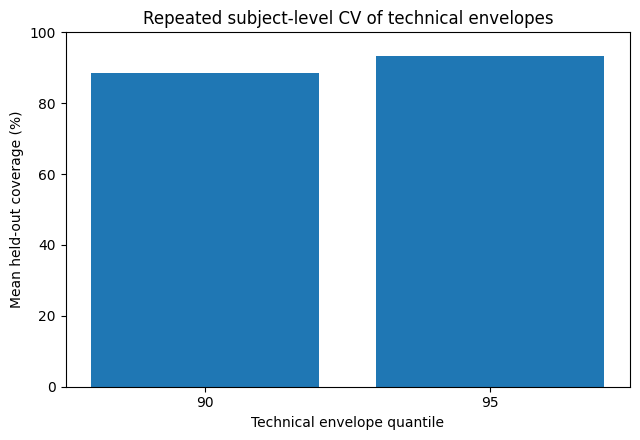

In [34]:

# Figure 1: repeated CV coverage for Q90 and Q95
plot_cv = (
    cv_summary.groupby("quantile")["mean_coverage_pct"]
    .mean()
    .reindex([90, 95])
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(plot_cv.index.astype(str), plot_cv.values)
ax.set_ylim(0, 100)
ax.set_ylabel("Mean held-out coverage (%)")
ax.set_xlabel("Technical envelope quantile")
ax.set_title("Repeated subject-level CV of technical envelopes")
plt.tight_layout()
plt.savefig(OUTDIR / "figure_cv_coverage_q90_q95.png", dpi=300, bbox_inches="tight")
plt.show()


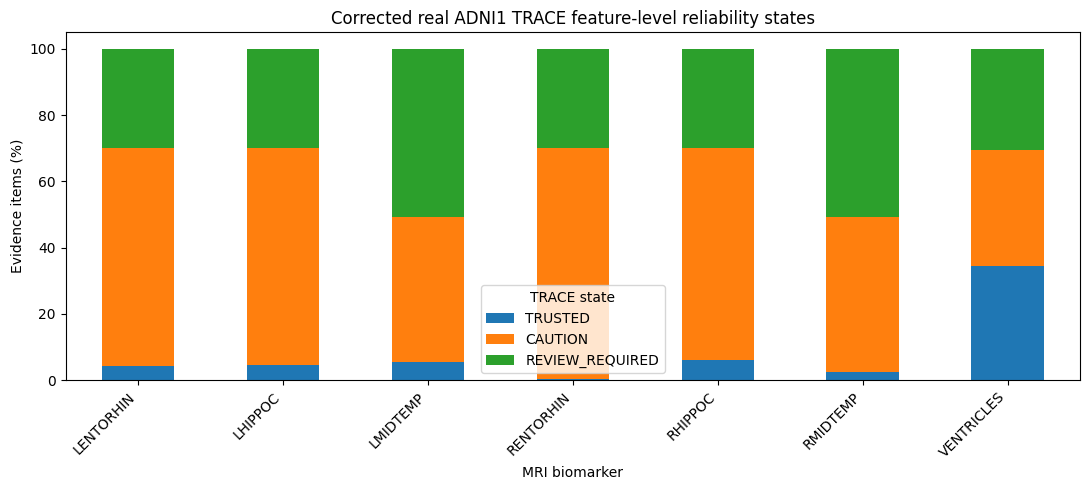

In [35]:

# Figure 2: feature-level primary Q90 TRACE states
plot_states = feature_state_pivot.reindex(
    columns=["TRUSTED", "CAUTION", "REVIEW_REQUIRED"]
)

ax = plot_states.plot(kind="bar", stacked=True, figsize=(11, 5))
ax.set_ylabel("Evidence items (%)")
ax.set_xlabel("MRI biomarker")
ax.set_title("Corrected real ADNI1 TRACE feature-level reliability states")
plt.xticks(rotation=45, ha="right")
plt.legend(title="TRACE state")
plt.tight_layout()
plt.savefig(OUTDIR / "figure_corrected_feature_trace_states.png", dpi=300, bbox_inches="tight")
plt.show()


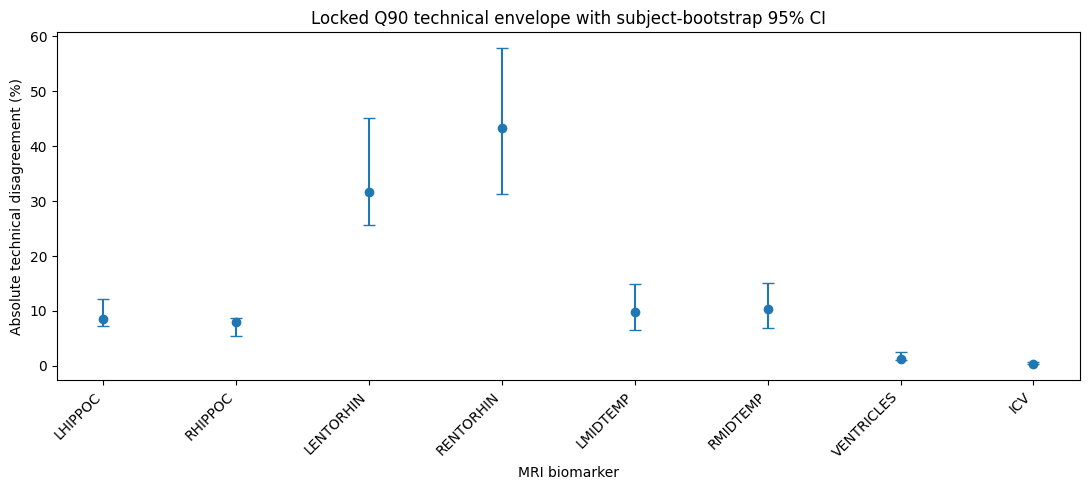

In [36]:

# Figure 3: Q90 threshold with bootstrap interval
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(thresholds))

vals = thresholds["q90_pct"].to_numpy()
lower = vals - thresholds["q90_boot_ci_low"].to_numpy()
upper = thresholds["q90_boot_ci_high"].to_numpy() - vals

ax.errorbar(
    x,
    vals,
    yerr=np.vstack([lower, upper]),
    fmt="o",
    capsize=4
)
ax.set_xticks(x)
ax.set_xticklabels(thresholds["feature"], rotation=45, ha="right")
ax.set_ylabel("Absolute technical disagreement (%)")
ax.set_xlabel("MRI biomarker")
ax.set_title("Locked Q90 technical envelope with subject-bootstrap 95% CI")
plt.tight_layout()
plt.savefig(OUTDIR / "figure_q90_bootstrap_thresholds.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. Aggregate exports

In [37]:

cv.to_csv(OUTDIR / "table_repeated_cv_all_folds.csv", index=False)
cv_summary.to_csv(OUTDIR / "table_repeated_cv_summary.csv", index=False)
thresholds.to_csv(OUTDIR / "table_locked_thresholds_bootstrap.csv", index=False)
reproc_sensitivity.to_csv(OUTDIR / "table_reprocessing_sensitivity.csv", index=False)
root_cause_summary.to_csv(OUTDIR / "table_unique_root_causes.csv", index=False)
feature_state_summary.to_csv(OUTDIR / "table_feature_trace_states_q90.csv", index=False)
package_sensitivity.to_csv(OUTDIR / "table_package_rule_sensitivity.csv", index=False)
q95_sensitivity.to_csv(OUTDIR / "table_feature_trace_states_q95_sensitivity.csv", index=False)
outcome_audit.to_csv(OUTDIR / "table_exploratory_outcome_audit.csv")

print("Aggregate/publication-oriented outputs:")
for p in sorted(OUTDIR.glob("*")):
    print(" -", p.name)


Aggregate/publication-oriented outputs:
 - figure_corrected_feature_trace_states.png
 - figure_cv_coverage_q90_q95.png
 - figure_q90_bootstrap_thresholds.png
 - manifest.json
 - table_exploratory_outcome_audit.csv
 - table_feature_trace_states_q90.csv
 - table_feature_trace_states_q95_sensitivity.csv
 - table_locked_thresholds_bootstrap.csv
 - table_package_rule_sensitivity.csv
 - table_repeated_cv_all_folds.csv
 - table_repeated_cv_summary.csv
 - table_reprocessing_sensitivity.csv
 - table_unique_root_causes.csv



## 15. Save the private gated participant-level file for 21-REAL

**Do not commit this CSV to GitHub.**


In [38]:

PRIVATE_GATE_PATH = Path("TRACE_ADNI1_20B_REAL_CORRECTED_GATED_PRIVATE.csv")

private_cols = [
    "RID",
    "LABEL",
    "TRACE_PACKAGE_STATE",
    "N_TRUSTED",
    "N_CAUTION",
    "N_REVIEW_FEATURES",
    "N_UNIQUE_HARD_ROOT_CAUSES",
    "ICV_HARD_REVIEW",
    "TEMP_HARD_REVIEW",
    "VENT_HARD_REVIEW",
    "OVERALL_QC_BOTH_PASS",
]

for f in FEATURES:
    for c in [
        f"BL_{f}",
        f"M12_{f}",
        f"{f}_ABS_LONG_PCT",
        f"{f}_TECH_Q90",
        f"{f}_TECH_Q95",
        f"{f}_SIGNAL_TO_TECH_Q90",
    ]:
        if c in gate_df.columns:
            private_cols.append(c)

for f in BIO_FEATURES:
    private_cols.append(f"{f}_TRACE_STATE")

private_gate = gate_df[private_cols].copy()
private_gate.to_csv(PRIVATE_GATE_PATH, index=False)

print("PRIVATE participant-level file saved:")
print(PRIVATE_GATE_PATH.resolve())
print("Rows:", len(private_gate))
print("DO NOT PUSH THIS FILE TO GITHUB.")


PRIVATE participant-level file saved:
/content/TRACE_ADNI1_20B_REAL_CORRECTED_GATED_PRIVATE.csv
Rows: 258
DO NOT PUSH THIS FILE TO GITHUB.


## 16. Reproducibility manifest

In [39]:

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    "notebook": "20B-REAL-CORRECTED",
    "seed": SEED,
    "inputs": {
        LONGITUDINAL_PATH.name: sha256_file(LONGITUDINAL_PATH),
        REPEAT_PATH.name: sha256_file(REPEAT_PATH),
    },
    "technical_reference": {
        "same_day_acquisition_pairs": int(len(acq)),
        "same_day_acquisition_subjects": int(acq["RID"].nunique()),
        "primary_threshold": "all-pair Q90 absolute percent disagreement",
        "conservative_sensitivity_threshold": "all-pair Q95 absolute percent disagreement",
        "threshold_uncertainty": "2000 subject-cluster bootstrap replicates",
        "cross_validation": f"{CV_REPEATS}x repeated {N_SPLITS}-fold subject-level CV",
    },
    "longitudinal_subjects": int(gate_df["RID"].nunique()),
    "outcome_labels_used_for_gate_calibration": False,
    "package_review_double_counts_bilateral_qc": False,
}

with open(OUTDIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

manifest


{'notebook': '20B-REAL-CORRECTED',
 'seed': 2027,
 'inputs': {'TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv': 'f627bd017e3287b2bad7b6894372e7c5c78bffa2e73f1c92f9d89d6274d03dea',
  'TRACE_ADNI1_repeat_pairs_REAL.csv': '3a600b5cf11df11d2511e51ebbc933eed8be3d04305b7b281271d058c37ab926'},
 'technical_reference': {'same_day_acquisition_pairs': 75,
  'same_day_acquisition_subjects': 60,
  'primary_threshold': 'all-pair Q90 absolute percent disagreement',
  'conservative_sensitivity_threshold': 'all-pair Q95 absolute percent disagreement',
  'threshold_uncertainty': '2000 subject-cluster bootstrap replicates',
  'cross_validation': '25x repeated 5-fold subject-level CV'},
 'longitudinal_subjects': 258,
 'outcome_labels_used_for_gate_calibration': False,
 'package_review_double_counts_bilateral_qc': False}

## 17. Final corrected readiness summary

In [40]:

print("============================================================")
print("20B-REAL-CORRECTED READINESS SUMMARY")
print("============================================================")

print(f"Primary same-day acquisition pairs: {len(acq)}")
print(f"Primary same-day acquisition subjects: {acq['RID'].nunique()}")
print(f"Longitudinal subjects gated: {gate_df['RID'].nunique()}")

print("\nREPEATED-CV COVERAGE SUMMARY")
display(
    cv_summary[
        [
            "feature",
            "quantile",
            "mean_coverage_pct",
            "median_coverage_pct",
            "sd_coverage_pct",
            "p10_coverage_pct",
            "p90_coverage_pct",
        ]
    ].round(2)
)

print("\nLOCKED TECHNICAL ENVELOPES")
display(
    thresholds[
        [
            "feature",
            "q90_pct",
            "q90_boot_ci_low",
            "q90_boot_ci_high",
            "q95_pct",
            "q95_boot_ci_low",
            "q95_boot_ci_high",
        ]
    ].round(3)
)

print("\nREPROCESSING SENSITIVITY")
display(reproc_sensitivity.round(2))

print("\nUNIQUE HARD-REVIEW ROOT CAUSES")
display(root_cause_summary.round(1))

print("\nPRIMARY FEATURE-LEVEL TRACE STATES — Q90 (%)")
display(feature_state_pivot.round(1))

print("\nSUBJECT PACKAGE STATE — DESCRIPTIVE")
print(gate_df["TRACE_PACKAGE_STATE"].value_counts())
print((100 * gate_df["TRACE_PACKAGE_STATE"].value_counts(normalize=True)).round(1))

print("\nPACKAGE RULE SENSITIVITY (%)")
display(
    package_sensitivity.pivot(
        index="trusted_min_rule",
        columns="state",
        values="pct"
    ).fillna(0).round(1)
)

print("\nQ95 FEATURE-LEVEL SENSITIVITY (%)")
display(
    q95_sensitivity.pivot(
        index="feature",
        columns="state",
        values="pct"
    ).fillna(0).round(1)
)

print("\nEXPLORATORY OUTCOME AUDIT — NOT USED FOR CALIBRATION")
display(outcome_audit)

print("\nREADINESS CHECKS")
checks = {
    "real_same_day_repeat_reference": len(acq) == 75,
    "subject_level_repeated_cv_completed": len(cv) > 0,
    "bootstrap_threshold_uncertainty_completed": thresholds["q90_boot_ci_low"].notna().all(),
    "real_longitudinal_application": gate_df["RID"].nunique() == 258,
    "feature_level_three_state_output_present":
        set(["TRUSTED", "CAUTION", "REVIEW_REQUIRED"]).issubset(
            set(feature_state_summary.loc[feature_state_summary["n"] > 0, "state"])
        ),
    "unique_root_cause_package_review": True,
    "outcome_blind_gate_calibration": True,
}

for name, passed in checks.items():
    print(f"{name}: {'PASS' if passed else 'CHECK'}")

print("\nPRIMARY INTERPRETATION")
print("Feature-level TRACE states are the primary gate output.")
print("Subject-package state is secondary/descriptive.")
print("Q90 is primary; Q95 is conservative sensitivity.")
print("No clinical outcome was used to select thresholds or gate rules.")


20B-REAL-CORRECTED READINESS SUMMARY
Primary same-day acquisition pairs: 75
Primary same-day acquisition subjects: 60
Longitudinal subjects gated: 258

REPEATED-CV COVERAGE SUMMARY


,feature,quantile,mean_coverage_pct,median_coverage_pct,sd_coverage_pct,p10_coverage_pct,p90_coverage_pct
0,ICV,90,88.46,88.89,10.08,76.65,100.0
1,ICV,95,93.26,93.75,7.55,85.71,100.0
2,LENTORHIN,90,88.41,88.24,8.45,76.99,100.0
3,LENTORHIN,95,93.96,93.75,6.41,86.10,100.0
4,LHIPPOC,90,88.79,92.31,9.30,76.65,100.0
5,LHIPPOC,95,93.04,93.33,7.07,80.50,100.0
6,LMIDTEMP,90,88.58,92.31,9.79,75.59,100.0
7,LMIDTEMP,95,93.33,93.75,7.28,84.62,100.0
8,RENTORHIN,90,88.82,88.24,9.05,76.92,100.0
9,RENTORHIN,95,93.22,93.75,7.47,83.85,100.0



LOCKED TECHNICAL ENVELOPES


,feature,q90_pct,q90_boot_ci_low,q90_boot_ci_high,q95_pct,q95_boot_ci_low,q95_boot_ci_high
0,LHIPPOC,8.601,7.166,12.108,11.366,8.271,13.742
1,RHIPPOC,7.933,5.411,8.783,8.783,7.394,10.806
2,LENTORHIN,31.664,25.581,45.072,44.764,29.555,58.409
3,RENTORHIN,43.390,31.265,57.851,54.097,40.230,62.255
4,LMIDTEMP,9.836,6.489,14.923,14.579,9.124,16.771
5,RMIDTEMP,10.373,6.932,15.032,13.269,8.695,18.114
6,VENTRICLES,1.171,1.019,2.531,2.273,1.119,3.929
7,ICV,0.365,0.265,0.771,0.717,0.349,0.985



REPROCESSING SENSITIVITY


...


Q95 FEATURE-LEVEL SENSITIVITY (%)


state,CAUTION,REVIEW_REQUIRED,TRUSTED
feature,,,
LENTORHIN,67.8,29.8,2.3
LHIPPOC,68.6,29.8,1.6
LMIDTEMP,48.4,50.8,0.8
RENTORHIN,70.2,29.8,0.0
RHIPPOC,68.2,29.8,1.9
RMIDTEMP,48.8,50.8,0.4
VENTRICLES,36.0,30.6,33.3



EXPLORATORY OUTCOME AUDIT — NOT USED FOR CALIBRATION


LABEL,pMCI,sMCI,All
TRACE_PACKAGE_STATE,,,
CAUTION,70,52,122
REVIEW_REQUIRED,67,66,133
TRUSTED,3,0,3
All,140,118,258



READINESS CHECKS
real_same_day_repeat_reference: PASS
subject_level_repeated_cv_completed: PASS
bootstrap_threshold_uncertainty_completed: PASS
real_longitudinal_application: PASS
feature_level_three_state_output_present: PASS
unique_root_cause_package_review: PASS
outcome_blind_gate_calibration: PASS

PRIMARY INTERPRETATION
Feature-level TRACE states are the primary gate output.
Subject-package state is secondary/descriptive.
Q90 is primary; Q95 is conservative sensitivity.
No clinical outcome was used to select thresholds or gate rules.


In [41]:
# Re-create and download the private gated file for 21-REAL

from google.colab import files
from pathlib import Path

FEATURES = [
    "LHIPPOC",
    "RHIPPOC",
    "LENTORHIN",
    "RENTORHIN",
    "LMIDTEMP",
    "RMIDTEMP",
    "VENTRICLES",
    "ICV",
]

BIO_FEATURES = [f for f in FEATURES if f != "ICV"]

PRIVATE_GATE_PATH = Path(
    "/content/TRACE_ADNI1_20B_REAL_CORRECTED_GATED_PRIVATE.csv"
)

private_cols = [
    "RID",
    "LABEL",
    "TRACE_PACKAGE_STATE",
    "N_TRUSTED",
    "N_CAUTION",
    "N_REVIEW_FEATURES",
    "N_UNIQUE_HARD_ROOT_CAUSES",
    "ICV_HARD_REVIEW",
    "TEMP_HARD_REVIEW",
    "VENT_HARD_REVIEW",
    "OVERALL_QC_BOTH_PASS",
]

for f in FEATURES:
    for c in [
        f"BL_{f}",
        f"M12_{f}",
        f"{f}_ABS_LONG_PCT",
        f"{f}_TECH_Q90",
        f"{f}_TECH_Q95",
        f"{f}_SIGNAL_TO_TECH_Q90",
    ]:
        if c in gate_df.columns:
            private_cols.append(c)

for f in BIO_FEATURES:
    private_cols.append(f"{f}_TRACE_STATE")

private_gate = gate_df[private_cols].copy()

private_gate.to_csv(
    PRIVATE_GATE_PATH,
    index=False
)

print("Saved:")
print(PRIVATE_GATE_PATH)
print("Rows:", len(private_gate))
print("Columns:", len(private_gate.columns))

files.download(str(PRIVATE_GATE_PATH))

Saved:
/content/TRACE_ADNI1_20B_REAL_CORRECTED_GATED_PRIVATE.csv
Rows: 258
Columns: 66


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>